In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, shutil, pathlib, json
import numpy as np
import jax
from jax import value_and_grad, jit, vmap, grad, random
import jax.numpy as jnp
import flax.linen as nn
import matplotlib.pyplot as plt
from absl import logging
import ml_collections
import optax

import torch

from typing import Any, Callable, Sequence, Optional, List, Tuple

import time
import wandb

# from action_angle_networks import train, analysis
# from action_angle_networks.simulation import harmonic_motion_simulation as hsim
# from action_angle_networks.configs.harmonic_motion import default as hm_default

from action_angle_networks.sk_layers import (
    GSBlock, GSympNet, MLP, MLPFlexible,
    PolarCoordinates,  InversePolarCoordinates,
    GotosCanonicalPolarCoordinates, InverseGotosCanonicalPolarCoordinates,
)
from action_angle_networks.sk_models import MyActionAngleNetwork

%config InlineBackend.figure_format = 'retina'
logging.set_verbosity(logging.INFO)

In [3]:
# Simulate 1d harmonic oscillator
#key = jax.random.PRNGKey(0)
# Simulate 1d harmonic oscillator

import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

@dataclass
class HarmonicParams:
    n: int
    m: np.ndarray         # (n,) masses per oscillator
    k_wall: float         # wall spring constant
    k_pair: float         # pairwise coupling spring constant
    A_modes: np.ndarray   # (n,) amplitudes per normal mode
    phi_modes: np.ndarray # (n,) phases per normal mode (radians)

def sample_harmonic_params(
    n: int,
    m_range: Tuple[float, float] = (1.0, 5.0),
    k_wall: float = 0.01,
    k_pair: float = 0.005,
    A_range: Tuple[float, float] = (1.0, 3.0),
    seed: Optional[int] = 0,
) -> HarmonicParams:
    rng = np.random.default_rng(seed)
    m = rng.uniform(*m_range, size=(n,)).astype(np.float64)
    # Normal-mode amplitudes/phases
    A_modes = rng.uniform(*A_range, size=(n,)).astype(np.float64)
    phi_modes = rng.uniform(0.0, 2*np.pi, size=(n,)).astype(np.float64)
    return HarmonicParams(
        n=n, m=m, k_wall=float(k_wall), k_pair=float(k_pair),
        A_modes=A_modes, phi_modes=phi_modes
    )

def _normal_mode_eigendecomposition(params: HarmonicParams):
    """
    Returns eigenvalues/eigenvectors for q¨ = M^{-1} L q.
    Repoに合わせて L = -(k_wall + n*k_pair) I + k_pair 1 1^T を用い、
    固有値は負になる（w = sqrt(-eigvals)）。
    """
    n = params.n
    I = np.eye(n)
    J = np.ones((n, n))
    L = -(params.k_wall + n * params.k_pair) * I + params.k_pair * J
    M_inv = np.diag(1.0 / params.m)
    M_inv_L = M_inv @ L
    eigvals, eigvecs = np.linalg.eig(M_inv_L)
    eigvals = eigvals.real
    eigvecs = eigvecs.real
    return eigvals, eigvecs  # (n,), (n,n)

def simulate_coupled_1d_harmonic(
    params: HarmonicParams, num_steps: int, dt: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Returns:
      t: (T,)
      q: (T, n) positions
      p: (T, n) momenta  (p = m * dq/dt)
      aux: dict with eigvals/eigvecs/w
    """
    n = params.n
    t = np.arange(num_steps, dtype=np.float64) * float(dt)

    # Normal modes
    eigvals, V = _normal_mode_eigendecomposition(params)
    w = np.sqrt(np.clip(-eigvals, a_min=0.0, a_max=None))  # angular freq

    # Mode-space trajectories
    Wt_phi = t[:, None] * w[None, :] + params.phi_modes[None, :]  # (T, n)
    q_mode = params.A_modes[None, :] * np.cos(Wt_phi)              # (T, n)
    qdot_mode = -params.A_modes[None, :] * (w[None, :]) * np.sin(Wt_phi)  # (T, n)

    # Map back to physical coords: q = V q_mode, qdot = V qdot_mode
    q = q_mode @ V.T
    qdot = qdot_mode @ V.T
    p = qdot * params.m[None, :]  # momentum = m * qdot

    aux = {"eigvals": eigvals, "eigvecs": V, "w": w}
    return t, q, p, aux

# # Example: quick sanity check
# if __name__ == "__main__":
#     n = 3
#     params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
#     T = 400
#     dt = 0.1
#     t, q, p, aux = simulate_coupled_1d_harmonic(params, num_steps=T, dt=dt)
#     print("q shape:", q.shape, "p shape:", p.shape)



In [ ]:
# Example: quick sanity check
n = 2
params = sample_harmonic_params(n=n, m_range=(1.0, 3.0), k_wall=0.01, k_pair=0.005, A_range=(1.0, 2.0), seed=42)
T = 1000
dt = 0.1
t, q, p, aux = simulate_coupled_1d_harmonic(params, num_steps=T, dt=dt)
print("q shape:", q.shape, "p shape:", p.shape)

q shape: (1000, 3) p shape: (1000, 3)


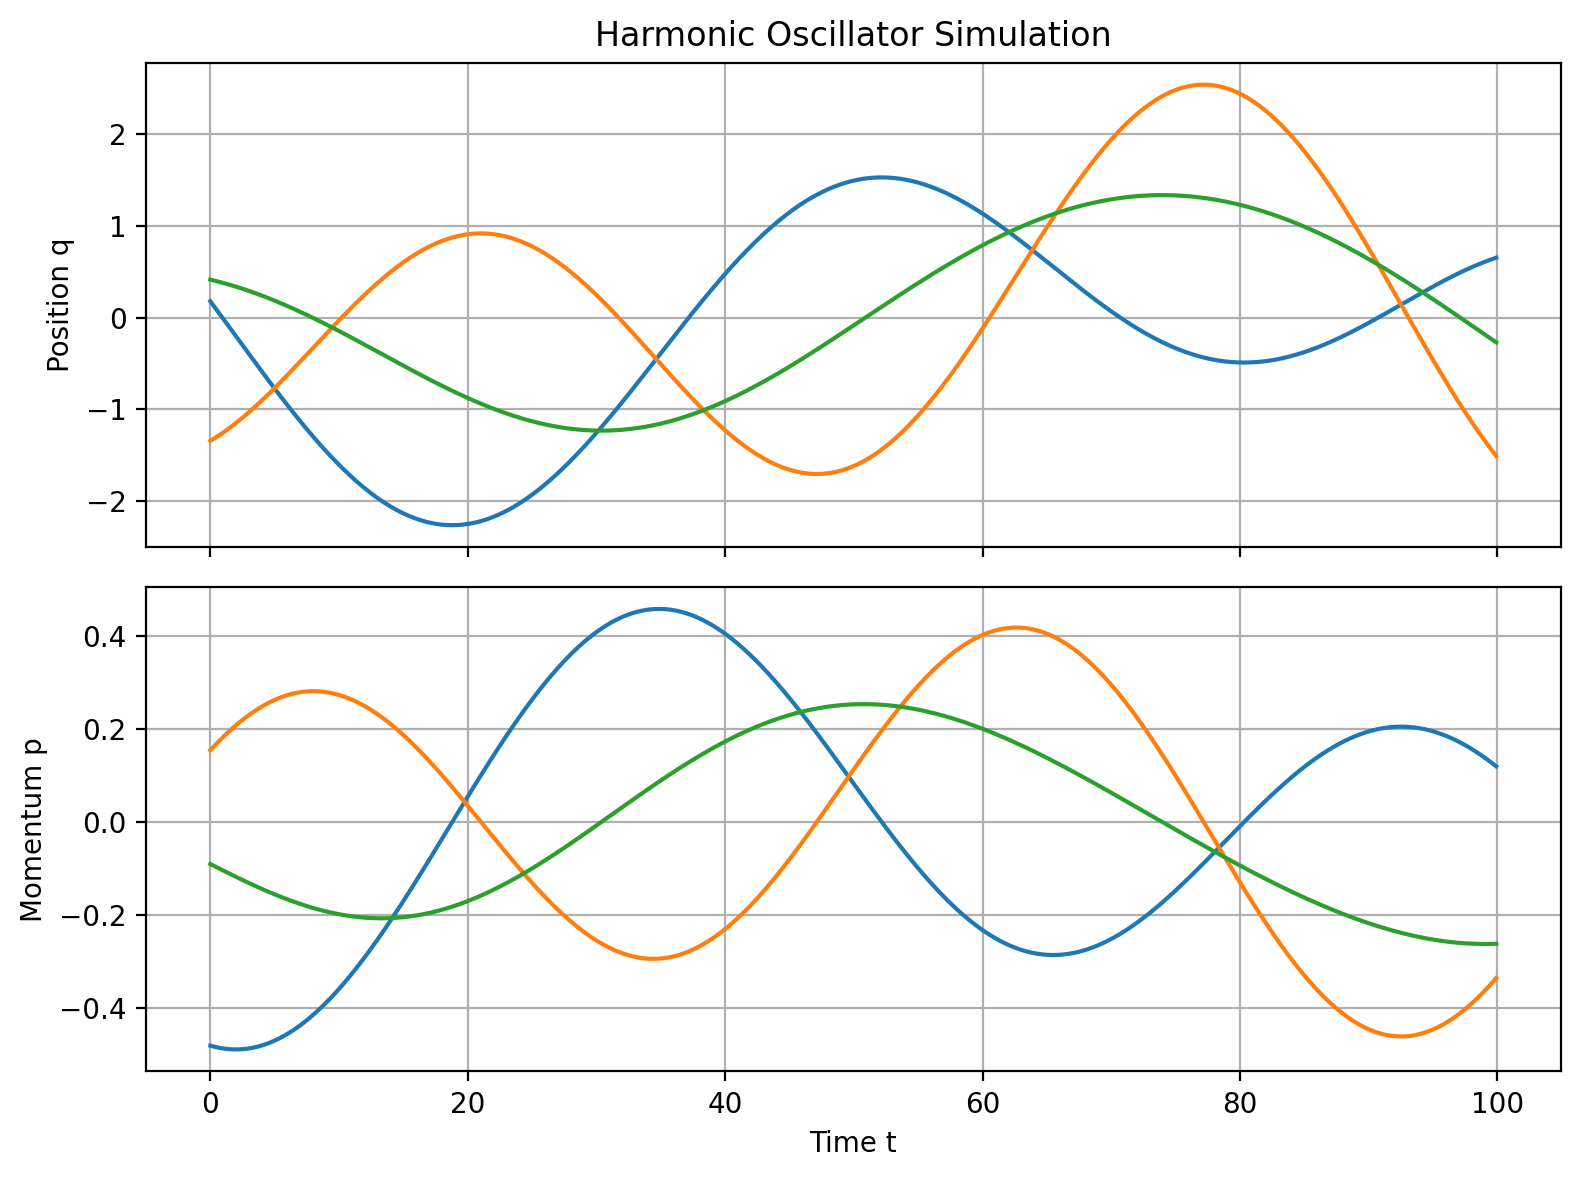

In [5]:
from matplotlib import pyplot as plt

# plot q and p
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, q)
ax[0].set_ylabel('Position q')
ax[0].set_title('Harmonic Oscillator Simulation')
ax[0].grid()
ax[1].plot(t, p)
ax[1].set_ylabel('Momentum p')
ax[1].set_xlabel('Time t')
ax[1].grid()
plt.tight_layout()
plt.show()

In [6]:
# t, q, p は前セルのシミュレーション出力。q, p の shape は (T, n)
T, n = q.shape
assert p.shape == (T, n)
dt = float(t[1] - t[0])

# 時系列で分割（情報漏洩を防ぐため、時間で切る）
frac_train = 0.1
frac_test  = 0.5
T_train = int(T * frac_train)
T_test  = int(T * frac_test)

q_train = jnp.asarray(q[:T_train])
p_train = jnp.asarray(p[:T_train])

q_test  = jnp.asarray(q[-T_test:])
p_test  = jnp.asarray(p[-T_test:])


In [7]:
print("Train shape:", q_train.shape, p_train.shape)
print("Test shape:", q_test.shape, p_test.shape)

Train shape: (100, 3) (100, 3)
Test shape: (500, 3) (500, 3)


# Create model & Train

In [ ]:

model = MyActionAngleNetwork(
    dim_config=n,
    dim_hidden=100,
    num_gsblocks=20,
    type_polar="canonical",
    activation=nn.sigmoid,
    mlp_res_connection=True
)


# model = MyActionAngleNetwork(
#     dim_config=n,
#     dim_hidden_list=[64, 64, 64],
#     num_gsblocks=20,
#     type_polar="canonical",
#     activation=nn.sigmoid,
#     mlp_res_connection=True,
#     theta_predictor="gradient",
# )


In [68]:
# Initialize model and count total parameters
import jax, jax.numpy as jnp

rng = jax.random.PRNGKey(0)
q0 = jnp.zeros((1, int(n)))
p0 = jnp.zeros((1, int(n)))
delta_t0 = jnp.asarray(0.1)

variables = model.init(rng, q0, p0, delta_t0)
params = variables['params']
num_params = sum(jax.tree_util.tree_leaves(jax.tree_util.tree_map(lambda x: x.size, params)))
print(f'Total parameters: {num_params}')


Total parameters: 5522


In [15]:


@jit
def train_step(params, opt_state, x, y, delta_t, alpha, key):
    # x: (B, 2n) current (q, p)
    # y: (B, 2n) target  (q, p)
    T = x.shape[0]
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)

    def loss_fn(pp):
        q_, p_, I, _ = model.apply({'params': pp}, q, p, delta_t, train=True, rngs={'noise': key})
        #x_ = jnp.concatenate([q_, p_], axis=-1)
        
        # prediction loss
        loss_q_se = ((q_ - y[:, :n]) ** 2).mean()
        loss_p_se = ((p_ - y[:, n:]) ** 2).mean()

        # actions should be constant
        loss_action = jnp.var(I, axis=0).sum()

        return loss_q_se + loss_p_se + alpha * loss_action

    loss, grads = value_and_grad(loss_fn)(params)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

@jit
def eval_batch(params, x, y, delta_t, key):
    n = x.shape[1] // 2
    q, p = x[:, :n], x[:, n:]  # (B, 3), (B, 3)
    
    q_, p_, _, _ = model.apply({'params': params}, q, p, delta_t, train=False, rngs={'noise': key})
    #x_ = jnp.concatenate([q_, p_], axis=-1)

    loss_q_mse = ((q_ - y[:, :n]) ** 2).mean()
    loss_p_mse = ((p_ - y[:, n:]) ** 2).mean()

    return loss_q_mse + loss_p_mse


In [16]:
# wandb.login()  # すでに環境変数 WANDB_API_KEY があれば不要
# run = wandb.init(
#     project="aan_scratch_harm_osc",
#     name="aan_scratch_test_harm_osc",
#     config={
#             "model": "MyActionAngleNetwork",
#             "num_gsblocks": 4,
#             "dim_hidden": 64,
#             "type_polar": "canonical",
#             "activation": "relu",
#             "T": 400,
#             "dt": 0.1,
#             "n": 3,
#             "opt": dict(optimizer="adamw", lr=3e-4, weight_decay=1e-4, grad_clip=1.0),
#             "rng": dict(train_seed=int(key[0]), eval_seed=int(eval_key[0])),
#         },
# )
                    
                 

In [17]:
key = random.PRNGKey(0)
eval_key  = random.PRNGKey(42)


In [ ]:
rng = jax.random.PRNGKey(0)
params = model.init(rng, jnp.array([[0.0,0.0]]), jnp.array([[0.0,0.0]]), jnp.asarray(0.1))["params"]

# オプティマイザ
tx = optax.adam(1e-3)
opt_state = tx.init(params)

In [ ]:
num_steps = 5000
delta_t_max = 10 # maximum jump (see Eq.(10) in the paper)

batch_size = 100
log_every = 100
test_time_jumps = [1,2,5,10,20,50]
alpha = 1 #0.5  # weight for action constancy loss

normalize_qp = True

print("Start training...")
print(f"num_steps: {num_steps}, delta_t_max: {delta_t_max}, batch_size: {batch_size}, log_every: {log_every}")
print(f"test_time_jumps: {test_time_jumps}")
print(f"alpha (weight for action constancy loss): {alpha}")


for step in range(1, num_steps + 1):
    rng, sub1, sub2, sub3 = jax.random.split(rng, 4)

    # jump幅をサンプル
    max_time_jump_for_step = 1 + (step / num_steps) * (delta_t_max - 1)
    jump = jax.random.randint(sub1, shape=(), minval=1, maxval=max_time_jump_for_step + 1)
    # jump_max = jax.random.randint(sub1, shape=(), minval=1, maxval=int( step/num_steps * delta_t_max ) + 1 )
    # jump = jax.random.randint(sub2, shape=(), minval=1, maxval=jump_max+1)
    # jumpはあくまでステップ幅であり実時間ではない、実時間を計算
    delta_t_scalar = jnp.asarray(dt * jump)

    # n_train - jump このペアを作る
    curr_q, curr_p = q_train[:-jump], p_train[:-jump]
    tgt_q, tgt_p = q_train[jump:], p_train[jump:]

    # 重複を許してbatch_size個サンプル
    batch_size = min(batch_size, curr_q.shape[0]) # curr_qの数がとても小さいときはそれを上限にする
    idx_sample = jax.random.choice(
        sub3, curr_q.shape[0], shape=(batch_size,), replace=False
    )
    batch = (
        curr_q[idx_sample], curr_p[idx_sample],
        tgt_q[idx_sample], tgt_p[idx_sample],
    )

    #batch = sample_train_batch(sub)
    # batch = train_curr_q[idx], train_curr_p[idx], train_tgt_q[idx],  train_tgt_p[idx],

    params, opt_state, train_loss = train_step(
        params=params,
        opt_state=opt_state,
        x=jnp.concatenate([batch[0], batch[1]], axis=-1),
        y=jnp.concatenate([batch[2], batch[3]], axis=-1),
        alpha=alpha,
        delta_t=delta_t_scalar,
        key=rng
    )

    if step % log_every == 0 or step == 1:

        test_loss_list = []
        for jump in test_time_jumps:
            test_curr_q, test_curr_p = q_test[:-jump], p_test[:-jump] # (T-jump, n)
            test_tgt_q, test_tgt_p = q_test[jump:], p_test[jump:] # (T-jump, n)
            delta_t_test = dt * jump
            test_loss_jump = eval_batch(
                params=params,
                x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
                y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
                delta_t=delta_t_test,
                key=eval_key
            )
            test_loss_list.append(test_loss_jump)
        
        test_str = ", ".join(f"jump={j}: {float(l):.6f}"
                            for j, l in zip(test_time_jumps, test_loss_list))
        print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss [{test_str}]")

        # print(f"step {step:5d}  train_loss {float(train_loss):.6f}  test_loss {float(test_loss_list):.6f}")
        # wandb.log({
        #     "train/loss": float(train_loss),
        #     "test/loss": float(test_loss),
        #     "step": step,
        # })



        # for jump in test_time_jumps:
        #     test_curr_q.append( q_test[:-jump] )
        #     test_curr_p.append( p_test[:-jump] )
        #     test_tgt_q.append( q_test[jump:] )
        #     test_tgt_p.append( p_test[jump:] )
        #     delta_t_test.append(jnp.repeat(dt * jump, q_test.shape[0]-jump))
        # test_curr_q = jnp.concatenate(test_curr_q, axis=0)
        # test_curr_p = jnp.concatenate(test_curr_p, axis=0)
        # test_tgt_q  = jnp.concatenate(test_tgt_q, axis=0)
        # test_tgt_p  = jnp.concatenate(test_tgt_p, axis=0)
        # delta_t_test = jnp.concatenate(delta_t_test, axis=0)

        
        # test_loss = eval_batch(
        #     params=params,
        #     x=jnp.concatenate([test_curr_q, test_curr_p], axis=-1), 
        #     y=jnp.concatenate([test_tgt_q, test_tgt_p], axis=-1),
        #     delta_t=delta_t_test,
        #     key=eval_key
        # )
        

Start training...
num_steps: 5000, delta_t_max: 10, batch_size: 100, log_every: 100
test_time_jumps: [1, 2, 5, 10, 20, 50]
alpha (weight for action constancy loss): 1
step     1  train_loss 683.157593  test_loss [jump=1: 789.265625, jump=2: 788.407532, jump=5: 789.539429, jump=10: 800.772583, jump=20: 789.122986, jump=50: 783.114136]
step   100  train_loss 1.961255  test_loss [jump=1: 419.401672, jump=2: 438.590912, jump=5: 479.301392, jump=10: 427.400269, jump=20: 468.812164, jump=50: 479.478455]
step   200  train_loss 1.138441  test_loss [jump=1: 383.698975, jump=2: 475.334930, jump=5: 463.750061, jump=10: 430.268799, jump=20: 457.643921, jump=50: 473.690063]
step   300  train_loss 0.765434  test_loss [jump=1: 393.692993, jump=2: 485.245605, jump=5: 434.634216, jump=10: 436.210266, jump=20: 439.875946, jump=50: 447.955688]
step   400  train_loss 0.550918  test_loss [jump=1: 411.066071, jump=2: 459.482544, jump=5: 423.626770, jump=10: 426.337402, jump=20: 431.288940, jump=50: 461.7850

In [22]:
# Roll out model predictions from initial state across full horizon

# Convert true series to JAX arrays
q_true = jnp.asarray(q)
p_true = jnp.asarray(p)
T_total = int(q_true.shape[0])
n_dim = int(q_true.shape[1])

# Initial state and per-step delta_t
q0_roll = q_true[:1].squeeze(axis=0) if q_true.ndim==2 else q_true[:1]
p0_roll = p_true[:1].squeeze(axis=0) if p_true.ndim==2 else p_true[:1]
delta_t_infer = jnp.asarray(float(dt))

def _step_fn(carry, _):
    q_curr, p_curr = carry
    q_next, p_next, _, _ = model.apply({'params': params}, q_curr, p_curr, delta_t_infer, train=False)
    return (q_next, p_next), (q_next, p_next)

# Rollout T_total-1 steps to get length T_total with the initial appended
(_, _), (qs_seq, ps_seq) = jax.lax.scan(_step_fn, (q0_roll, p0_roll), None, length=max(T_total-1, 0))
q_pred = jnp.concatenate([q0_roll[None,...], qs_seq], axis=0) if T_total>0 else q0_roll
p_pred = jnp.concatenate([p0_roll[None,...], ps_seq], axis=0) if T_total>0 else p0_roll

# Remove batch axis
q_pred = jnp.squeeze(q_pred, axis=1) if q_pred.ndim==3 else q_pred
p_pred = jnp.squeeze(p_pred, axis=1) if p_pred.ndim==3 else p_pred

print('q_pred shape:', q_pred.shape, 'p_pred shape:', p_pred.shape)


q_pred shape: (1000, 3) p_pred shape: (1000, 3)


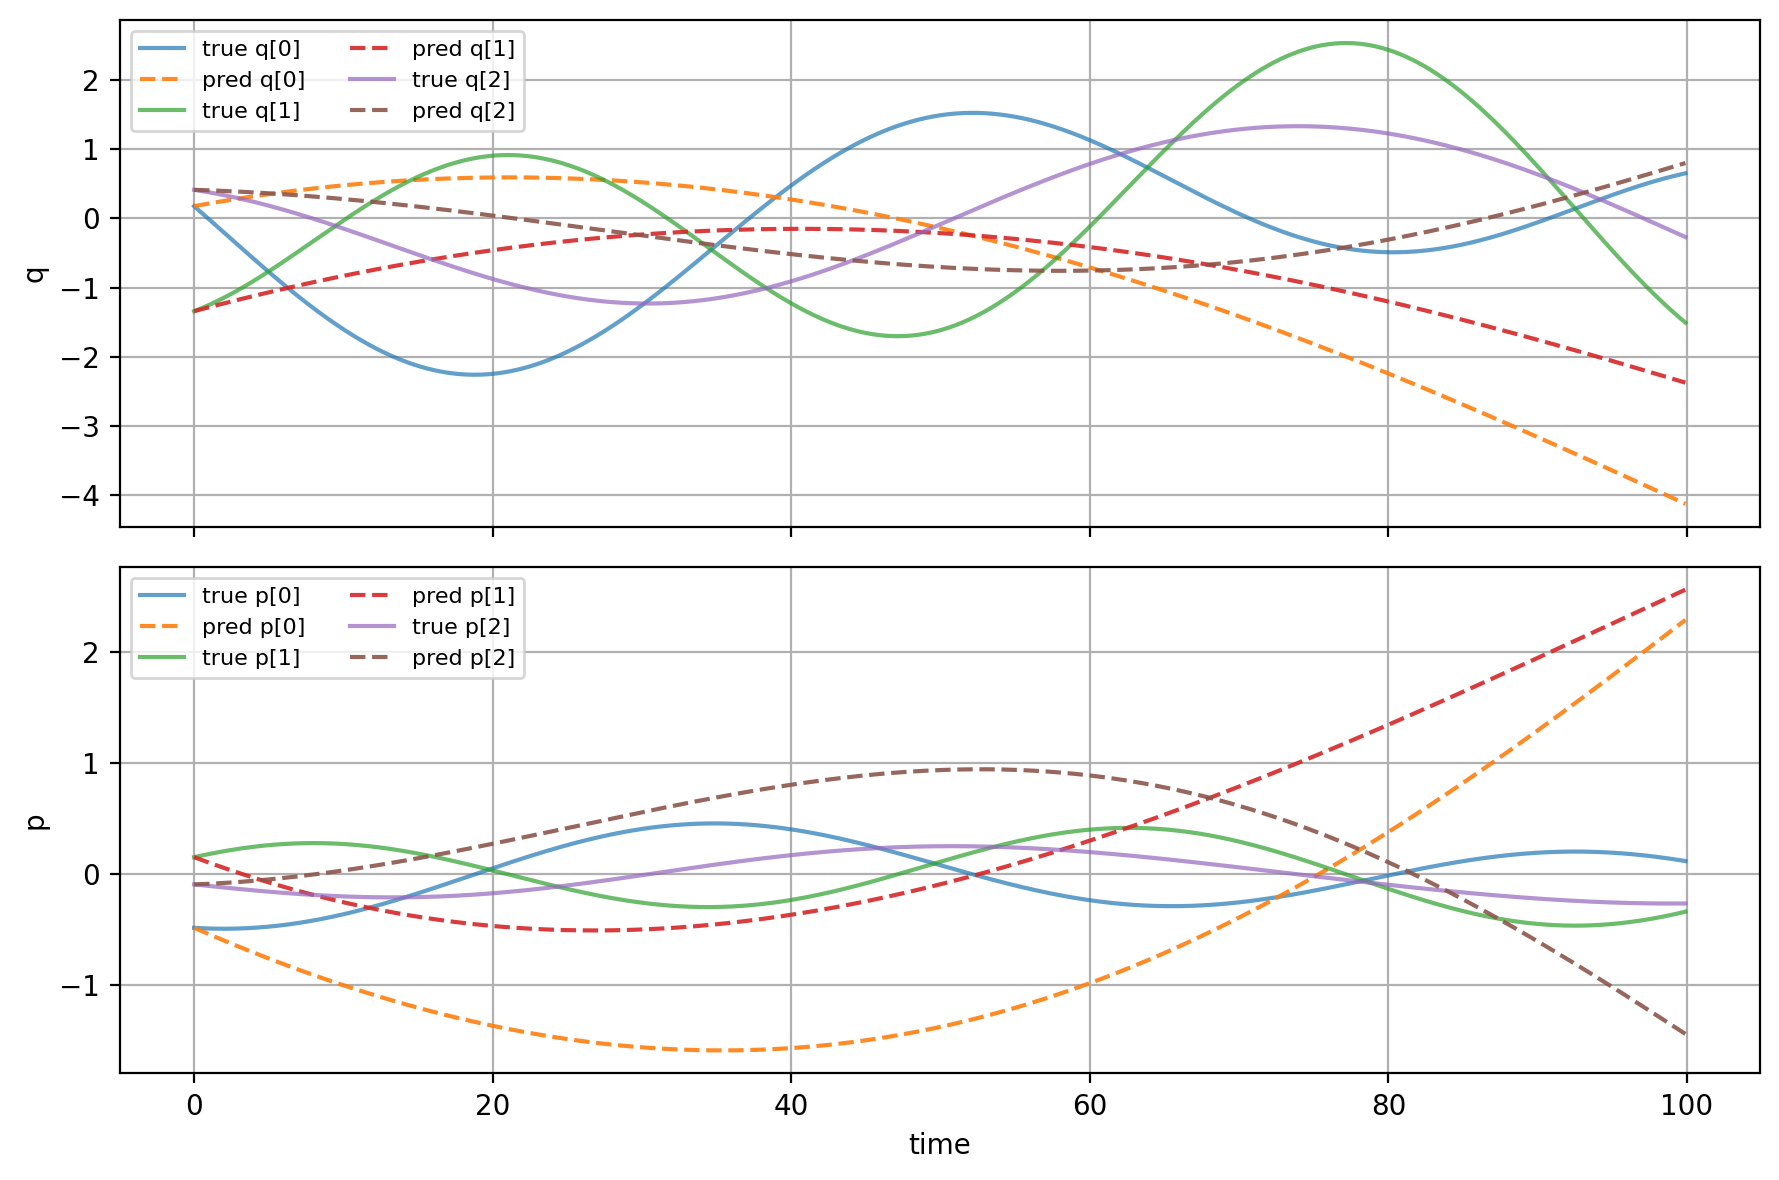

In [23]:
# Plot true vs predicted trajectories
import matplotlib.pyplot as plt
t_arr = np.asarray(t)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Positions
for i in range(q_pred.shape[1]):
    axes[0].plot(t_arr, np.asarray(q)[:, i], label=f'true q[{i}]', alpha=0.7)
    axes[0].plot(t_arr, np.asarray(q_pred)[:, i], '--', label=f'pred q[{i}]', alpha=0.9)
axes[0].set_ylabel('q')
axes[0].grid(True)
axes[0].legend(ncol=2, fontsize=8)

# Momenta
for i in range(p_pred.shape[1]):
    axes[1].plot(t_arr, np.asarray(p)[:, i], label=f'true p[{i}]', alpha=0.7)
    axes[1].plot(t_arr, np.asarray(p_pred)[:, i], '--', label=f'pred p[{i}]', alpha=0.9)
axes[1].set_ylabel('p')
axes[1].set_xlabel('time')
axes[1].grid(True)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()
